In [3]:
import pysmile_license
import pysmile
import numpy as np
import random
import csv
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display,clear_output
from EDAspy.optimization import UMDAc, EGNA, EMNA

c:\Users\SergioBeamonteGonzal\AppData\Local\Programs\Python\Python313\Lib\site-packages\pgmpy\estimators\__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


In [ ]:
from id_recovery import IDRecovery, AveragedExperiment, BatchExperimenter


In [ ]:
base_config = {
    # 'xdsl_path': r"example\bypass2\network-bypass2.xdsl", 
    # 'rules_csv': r"example\bypass2\reglas_generadas.csv", 
    # 'xdsl_path': r"example\VentureTwoWay\Venture Two Way.xdsl", 
    # 'rules_csv': r"example\VentureTwoWay\reglas_generadas.csv", 
    'xdsl_path': r"example\nhlv1\network-nhlv1.xdsl", 
    'rules_csv': r"example\nhlv1\reglas_generadas.csv", 
    'min_max_ut': True,             
    'u_range' : (0, 10),
    'alpha' : 0.5,
    'elite_factor' : 0.0,
    'n_decision_rules' : 10,
    'fitness_type':"regret",
    'stop_mode':"top30",
    'optimizer_type':"umda" 
}

# rec_model = IDRecovery(**base_config)
# rec_model.run(g=300, i=50)
# rec_model.net.write_file("recovered_fixed.xdsl")

batch = BatchExperimenter(
        n_experiments=1,              
        shuffle_rules_per_run=True,  
        **base_config
    )
mean_model, best_global_model = batch.run_batch(g=100, i=100, target_fitness=1e-5)


In [7]:
class IDRecoveryVisualizer:
    def __init__(self, model):
        """
        Toma una instancia de IDRecovery o AveragedExperiment que ya ha sido entrenada.
        """
        self.model = model

    def visualizar_historial(self):
        if not self.model.history:
            print("No hay datos. Ejecuta run() en el modelo primero.")
            return

        # --- PRECALCULAR LÍMITES GLOBALES ---
        all_errors = np.concatenate([data['errors'] for data in self.model.history])
        global_min_err = np.min(all_errors)
        global_max_err = np.max(all_errors)
        
        all_fitness = np.concatenate([data['fitness'] for data in self.model.history])
        global_min_fit = np.min(all_fitness)
        global_max_fit = np.max(all_fitness)
        
        bins_error = np.linspace(global_min_err, global_max_err, 40)
        bins_fitness = np.linspace(global_min_fit, global_max_fit, 40)
        bins_accuracy = np.linspace(0, 100, 40) 

        # 1. CREAMOS LA FIGURA UNA SOLA VEZ
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))
        plt.close(fig) # Evitamos que Jupyter la dibuje vacía antes de tiempo
        
        # 2. CREAMOS UNA ZONA DE SALIDA ESPECÍFICA PARA EL GRÁFICO
        out = widgets.Output()

        def _update_plot(change):
            # Extraemos el valor dependiendo de si lo llama el slider o nuestra llamada inicial
            gen_idx = change['new'] if isinstance(change, dict) else change
            
            data = self.model.history[gen_idx]
            gen = data['gen']
            errors = data['errors']
            fitness = data['fitness']
            accuracies = data['accuracies']
            
            threshold = np.median(fitness) 
            
            survivors_err = errors[fitness <= threshold]
            discarded_err = errors[fitness > threshold]
            survivors_fit = fitness[fitness <= threshold]
            discarded_fit = fitness[fitness > threshold]
            survivors_acc = accuracies[fitness <= threshold]
            discarded_acc = accuracies[fitness > threshold]

            with out:
                # wait=True es vital: no borra el plot viejo hasta tener el nuevo listo
                clear_output(wait=True) 
                
                # 3. LIMPIAMOS LOS EJES (Pero no destruimos la figura)
                ax1.cla()
                ax2.cla()
                ax3.cla()

                # AX1: ERROR
                ax1.hist([discarded_err, survivors_err], bins=bins_error, stacked=True, 
                         color=['gray', 'red'], label=['Descartados', 'Seleccionados'])
                ax1.set_title(f"Gen {gen}: Distribución Error Real (MSE)")
                ax1.set_xlabel("MSE")
                ax1.set_ylabel("Individuos")
                ax1.set_xlim(global_min_err, global_max_err)
                ax1.legend()
                
                # AX2: FITNESS
                ax2.hist([discarded_fit, survivors_fit], bins=bins_fitness, stacked=True, 
                         color=['gray', 'blue'], label=['Descartados', 'Seleccionados'])
                fit_label = "Reglas Falladas (Binario)" if getattr(self.model, 'fitness_type', '') == 'binary' else "Pérdida de Utilidad (Regret)"
                ax2.set_title(f"Gen {gen}: Distribución Fitness")
                ax2.set_xlabel(fit_label)
                ax2.set_ylabel("Individuos")
                ax2.set_xlim(global_min_fit, global_max_fit)
                ax2.legend()
                
                # AX3: PRECISIÓN
                ax3.hist([discarded_acc, survivors_acc], bins=bins_accuracy, stacked=True, 
                         color=['gray', 'green'], label=['Descartados', 'Seleccionados'])
                ax3.set_title(f"Gen {gen}: Precisión Global (% del Total)")
                ax3.set_xlabel("% de TODAS las Reglas cumplidas al 100%")
                ax3.set_ylabel("Individuos")
                ax3.set_xlim(0, 100)
                ax3.legend()

                plt.tight_layout()
                # Mostramos la figura reutilizada
                display(fig)

        slider = widgets.IntSlider(min=0, max=len(self.model.history)-1, step=1, 
                                   description='Generación:', continuous_update=False, 
                                   layout=widgets.Layout(width='500px'))
        
        play = widgets.Play(min=0, max=len(self.model.history)-1, step=1, 
                            interval=600, description="Navegar")
        
        widgets.jslink((play, 'value'), (slider, 'value'))
        
        # Conectamos el slider a nuestra función manual
        slider.observe(_update_plot, names='value')
        
        ui = widgets.HBox([play, slider])
        
        display(ui, out)
        
        # Forzamos la primera actualización para que se vea el frame 0 al cargar
        _update_plot(0)
    
    def plot_evolution_curves(self):
        if not self.model.history:
            print("No hay datos que plotear. Ejecuta run() en el modelo primero.")
            return

        gens = [data['gen'] for data in self.model.history]
        mean_errors = [np.mean(data['errors']) for data in self.model.history]
        mean_fitness = [np.mean(data['fitness']) for data in self.model.history]
        mean_accuracies = [np.mean(data['accuracies']) for data in self.model.history]

        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

        ax1.plot(gens, mean_errors, marker='o', color='red', linestyle='-')
        ax1.set_title("Evolución del Error Real Medio (MSE)")
        ax1.set_xlabel("Generación")
        ax1.set_ylabel("MSE Medio de la Población")
        ax1.grid(True)

        fit_label = "Reglas Falladas (Binario)" if getattr(self.model, 'fitness_type', '') == 'binary' else "Pérdida de Utilidad (Regret)"
        ax2.plot(gens, mean_fitness, marker='o', color='blue', linestyle='-')
        ax2.set_title(f"Evolución del Fitness Medio\n({fit_label})")
        ax2.set_xlabel("Generación")
        ax2.set_ylabel("Fitness Medio de la Población")
        ax2.grid(True)

        ax3.plot(gens, mean_accuracies, marker='o', color='green', linestyle='-')
        ax3.set_title("Evolución de la Precisión Media")
        ax3.set_xlabel("Generación")
        ax3.set_ylabel("% Medio de Reglas Cumplidas")
        ax3.grid(True)

        plt.tight_layout()
        plt.show()

    def get_history_means(self):
        if not self.model.history:
            print("No hay datos para extraer. Ejecuta run() en el modelo primero.")
            return None

        means_data = []
        for data in self.model.history:
            means_data.append({
                'Iteration': data['gen'],
                'Mean_MSE': np.mean(data['errors']),
                'Mean_Fitness': np.mean(data['fitness']),
                'Mean_Accuracy': np.mean(data['accuracies'])
            })
            
        return means_data

In [8]:
visualizador = IDRecoveryVisualizer(mean_model)
visualizador.visualizar_historial()

Output()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

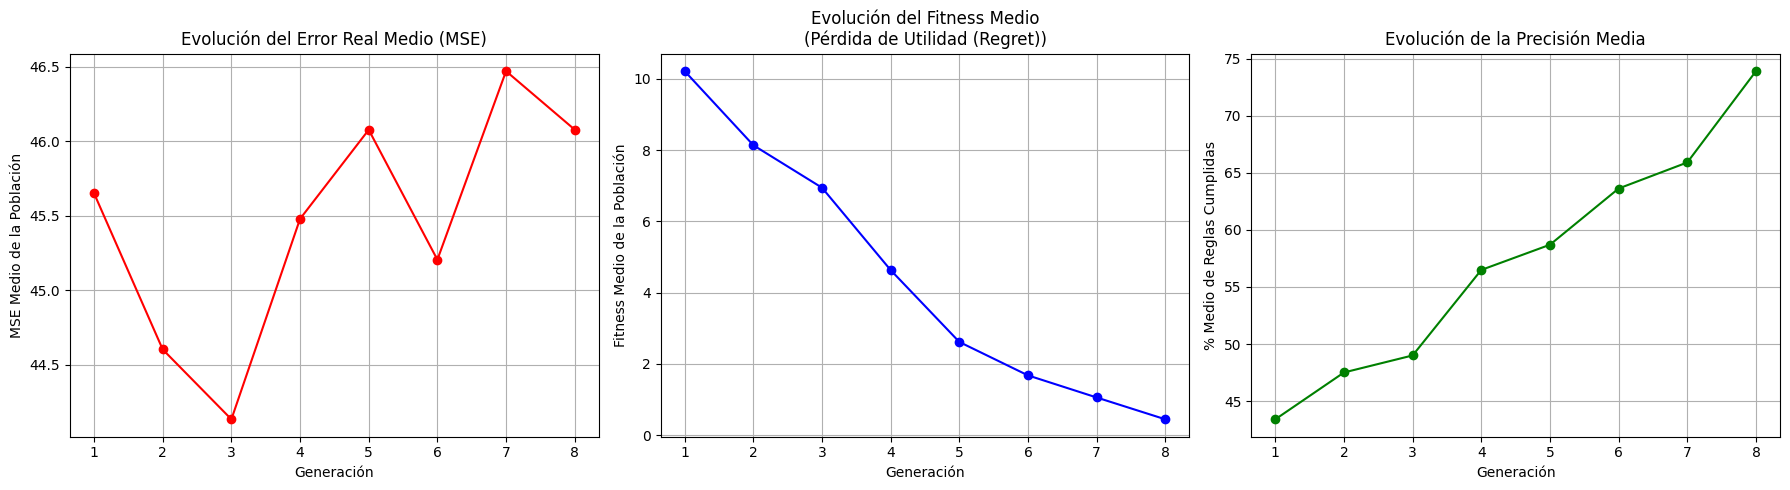

In [9]:
visualizador.plot_evolution_curves()

In [25]:
class RuleDecoder:
    """
    Clase auxiliar para decodificar y mostrar en formato legible humano 
    las reglas matemáticas optimizadas por la clase IDRecovery.
    """
    def __init__(self, net, rules):
        # Recibe la red de PySMILE y las reglas compiladas del optimizador
        self.net = net
        self.rules = rules

    def get_human_readable_rules(self):
        """
        Decodifica las reglas matemáticas internas y devuelve una lista 
        de diccionarios legibles para humanos.
        """
        readable_rules = []
        
        for r in self.rules:
            target_handle = self.net.get_node(r['node'])
            target_name = self.net.get_node_name(target_handle)
            action_name = self.net.get_outcome_id(target_handle, r['a_idx'])
            
            remainder = r['c_idx']
            context = {}
            
            for p in reversed(self.net.get_parents(target_handle)):
                n_outcomes = self.net.get_outcome_count(p)
                state_idx = remainder % n_outcomes
                remainder = remainder // n_outcomes
                
                parent_name = self.net.get_node_name(p)
                state_name = self.net.get_outcome_id(p, state_idx)
                
                context[parent_name] = state_name
            
            # Invertimos el orden para que visualmente vaya de padres a hijos
            context = {k: context[k] for k in reversed(list(context.keys()))}
            
            readable_rules.append({
                'Nodo_Decision': target_name,
                'Contexto': context,
                'Accion_Optima': action_name
            })
            
        return readable_rules

    def print_decoded_rules(self):
        """
        Imprime las reglas decodificadas por consola en un formato amigable.
        """
        rules = self.get_human_readable_rules()
        print("\n--- REGLAS DECODIFICADAS (HUMAN READABLE) ---")
        for i, rule in enumerate(rules):
            ctx_str = ", ".join([f"[{k}: '{v}']" for k, v in rule['Contexto'].items()])
            print(f"Regla {i+1} | SI {ctx_str}  --->  ENTONCES {rule['Nodo_Decision']} = '{rule['Accion_Optima']}'")

In [28]:
decoder = RuleDecoder(net=mean_model.net, rules=mean_model.train_rules)
decoder.print_decoded_rules()

AttributeError: 'AveragedExperiment' object has no attribute 'net'